In [40]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
#load Iris dataset
df= load_iris()

X= iris.data
Y= iris.target

print("Original shape of data:", X.shape)



Original shape of data: (150, 4)


In [41]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA(n_components=0.95)
pca.fit(X_scaled)

PCA(n_components=0.95)

In [42]:
X_reduced = pca.transform(X_scaled)
print("Reduced shape of data:",X_reduced.shape)

Reduced shape of data: (150, 2)


In [43]:
print("Number of components selected:",pca.n_components_)
print("Explained Variance Ratio:",pca.explained_variance_ratio_)
print("Total Variance Retained:",
np.sum(pca.explained_variance_ratio_))

Number of components selected: 2
Explained Variance Ratio: [0.72962445 0.22850762]
Total Variance Retained: 0.9581320720000163


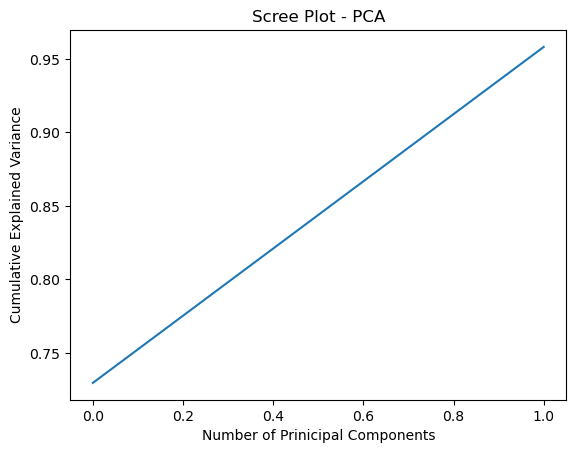

In [44]:
plt.figure()
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("Number of Prinicipal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Scree Plot - PCA")
plt.show()

In [45]:
y=df['target']

In [46]:
X_train,X_test,y_train,y_test = train_test_split(
    X_reduced, y, test_size=0.2,random_state=42)

model=LogisticRegression()
model.fit(X_train,y_train)

LogisticRegression()

In [48]:
y_pred = model.predict(X_test)
accuracy= accuracy_score(y_test,y_pred)
print("Model Accuracy after PCA:",accuracy)

Model Accuracy after PCA: 0.9


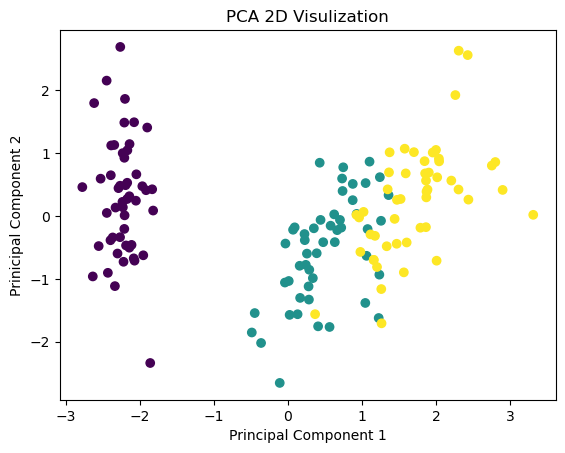

In [49]:
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_scaled)
plt.figure()
plt.scatter(X_2d[:, 0], X_2d[:, 1],c=y)
plt.xlabel("Principal Component 1")
plt.ylabel("Prinicipal Component 2")
plt.title("PCA 2D Visulization")
plt.show()